# DQN Backtesting

<div class="alert alert-success">In this notebook, I backtest the DQN model performance.</div> 

Import all necessary libraries

In [77]:

import json
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import torch



In [78]:
def convert_data_to_state(file_path: str, window: int = 60) -> tuple[np.ndarray, np.ndarray]:
    features = ['RSI_norm', 'MACD_line_norm', 'MACD_signal_norm', 'Volume_norm', 'Return']
    X = []
    metadata = []
    try:
        data = pd.read_parquet(file_path, engine='pyarrow')
        if len(data) < 100: # minimum 40 days of data (applicable to validation data)
            return None, None
        for i in range(len(data) - window + 1): 
            X.append(data[features].iloc[i:i+window].values)
            metadata.append({
                'target': data['Target'].iloc[i+window-1], 
                'date': data.index[i+window-1], 
                'close': data['Close'].iloc[i+window-1]})
        return np.array(X), np.array(metadata)
    except Exception as e:
        print(f"An error occurred while importing data: {e}")
        return None, None

In [79]:
file_path = "dataset_validation/AAPL.parquet"

In [86]:
print("#" * 40 + " -Start- "+"#" * 40)
print("\n", chr(128994),"The ", file_path, " is selected for testing the data loading...")
state, metadata = convert_data_to_state(file_path) # read file content and convert them
assert state is not None and metadata is not None, "State conversion failed."
print("\n", chr(128992), "This file has ", state.shape[0], " days of observations.")
assert state.shape[0] == len(metadata), "Mismatch between features and metadata length."

source_data = pd.read_parquet(file_path, engine='pyarrow') # (n rows, 8 features)
obs_index = state.shape[0] - 1
source_index = source_data.shape[0] - 1 
assert source_data.iloc[source_index]['RSI_norm'] == state[obs_index][-1][0], "RSI mismatch."
assert source_data.iloc[source_index]['MACD_line_norm'] == state[obs_index][-1][1], "MACD_line mismatch."
assert source_data.iloc[source_index]['MACD_signal_norm'] == state[obs_index][-1][2], "MACD_signal mismatch."
assert source_data.iloc[source_index]['Volume_norm'] == state[obs_index][-1][3], "Volume mismatch."
assert source_data.iloc[source_index]['Return'] == state[obs_index][-1][4], "Return mismatch."
print("\n", chr(128640), "Test passed")



indicator = "Indicator"
print("\n🍋 Source's data shape:", source_data.shape if source_data is not None else "Not Enough data available!")
print("🍀 State data shape for observations:", state.shape if state is not None else "Not Enough data available!")
print(f"\n{"Indicator":<15}|{"🍋 Source at index:" + str(source_index):<30}|{"🍀 State at index: " + str(obs_index):<30}", \
      f"\n{"RSI":<15}|{source_data.iloc[source_index]['RSI_norm']:<30}|{state[obs_index][-1][0]}", \
      f"\n{"MACD_line":<15}|{source_data.iloc[source_index]['MACD_line_norm']:<30}|{state[obs_index][-1][1]}",\
      f"\n{"MACD_signal":<15}|{source_data.iloc[source_index]['MACD_signal_norm']:<30}|{state[obs_index][-1][2]}", \
      f"\n{"Volume":<15}|{source_data.iloc[source_index]['Volume_norm']:<30}|{state[obs_index][-1][3]}", \
      f"\n{"Return":<15}|{source_data.iloc[-1]['Return']:<30}|{state[obs_index][-1][4]}")

print(f"\n{"🍋 Source value":<30}|{"🍀 Observation value":<30}", \
      f"\n{"🍊 Target: " + str(source_data.iloc[-1]['Target']):<30}|{"🍊 Target:" + str(metadata[-1]['target']):<30}")

######################################## -Start- ########################################

 🟢 The  dataset_validation/AAPL.parquet  is selected for testing the data loading...

 🟠 This file has  1084  days of observations.

 🚀 Test passed

🍋 Source's data shape: (1143, 8)
🍀 State data shape for observations: (1084, 60, 5)

Indicator      |🍋 Source at index:1142        |🍀 State at index: 1083         
RSI            |0.0020257873413642357         |0.0020257873413642357 
MACD_line      |0.2627894979269029            |0.2627894979269029 
MACD_signal    |0.5994431808071399            |0.5994431808071399 
Volume         |-0.8847623815331738           |-0.8847623815331738 
Return         |0.0018224236954367257         |0.0018224236954367257

🍋 Source value                |🍀 Observation value            
🍊 Target: 259.4800109863281   |🍊 Target:259.4800109863281    


The Q-Network:

In [87]:
import torch.nn as nn

class QNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(5, out_channels=64, kernel_size=5),
            nn.ReLU(),
            nn.Conv1d(64, out_channels=128, kernel_size=3),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 54, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 3),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(0) 
        x = x.transpose(1, 2) # Changing the shape from (1, 60, 5) to (1, 5, 60)
        return self.network(x)

In [88]:
cwd = Path.cwd()
model_path = cwd / "rlmodel" / "rl_dqn.pth"
assert model_path.exists(), f"chr(128992) Model not found at {model_path}!"
device = torch.device(torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu")

q_network = QNetwork().to(device)
q_network.load_state_dict(torch.load(model_path))



<All keys matched successfully>

In [89]:
metadata[0]

{'target': np.float64(142.0),
 'date': Timestamp('2021-08-24 00:00:00'),
 'close': np.float64(149.6199951171875)}

Processing through the all observations in validation data for Apple stock. The state and metadate variables are already set.

In [90]:
results = []
true_tentative = 0
true_positive = 0
true_negative = 0
false_tentative = 0
false_positive = 0
false_negative = 0

for observation, metadata in zip (state, metadata):
    # print(f"Observation shape: {observation.shape}, Metadata: {metadata}")
    with torch.no_grad():
    # since now I am using np.float32(60, 5) shape observation, I need to change it to torch.tensor(1, 60, 5) shape before passing to the network
        obs = torch.tensor(observation, dtype=torch.float32).to(device)
        q_values = q_network(obs)
        action_index = int(torch.argmax(q_values, dim=1).item())
    price_return = (metadata['target'] - metadata['close']) / metadata['close']

    # Determine actual trend: 0=hold, 1=buy (up), 2=sell (down)
    if price_return > 0.10:  # More than 10% increase
        actual_trend = 1  # Buy
    elif price_return < -0.10:  # More than 10% decrease
        actual_trend = 2  # Sell
    else:
        actual_trend = 0  # Hold
    
    if action_index == 0 and actual_trend == 0:
        """Added extra tentative sentiment."""
        reward = 1.0
        true_tentative += 1
    elif action_index == 1 and actual_trend == 1:
        reward = 2.0
        true_positive += 1
    elif action_index == 2 and actual_trend == 2:
        reward = 2.0
        true_negative += 1
    elif action_index == 0 and actual_trend == 1: 
        """Missed the opportunity"""
        reward = -1.0
        false_tentative += 1
    elif action_index == 0 and actual_trend == 2:
        """Couldn't avoid the loss"""
        reward = -1.0
        false_tentative += 1
    elif action_index == 1 and actual_trend == 2:
        """ Harsh penalty for buy advice for a loss"""
        reward = -2.0
        false_positive += 1
    elif action_index == 1 and actual_trend == 0:
        """Wrong buy advice"""
        reward = -1.0
        false_positive += 1
    elif action_index == 2 and actual_trend == 1:
        """Sold before a rise, missed the opportunity"""
        reward = -2.0
        false_negative += 1
    else:
        reward = -1.0 
        false_negative += 1
    color = "green" if action_index == actual_trend else "red"
    results.append({
        'date': metadata['date'],
        'close': metadata['close'],
        'target': metadata['target'],
        'action': action_index,
        'actual_trend': actual_trend,
        'color': color
        })

In [91]:
print(results[-1])

{'date': Timestamp('2025-12-16 00:00:00'), 'close': np.float64(274.6099853515625), 'target': np.float64(259.4800109863281), 'action': 0, 'actual_trend': 0, 'color': 'green'}


In [92]:
df = pd.DataFrame(results)
print(df.head())

        date       close      target  action  actual_trend  color
0 2021-08-24  149.619995  142.000000       0             0  green
1 2021-08-25  148.360001  143.289993       0             0  green
2 2021-08-26  147.539993  142.899994       0             0  green
3 2021-08-27  148.600006  142.809998       0             0  green
4 2021-08-30  153.119995  141.509995       0             0  green


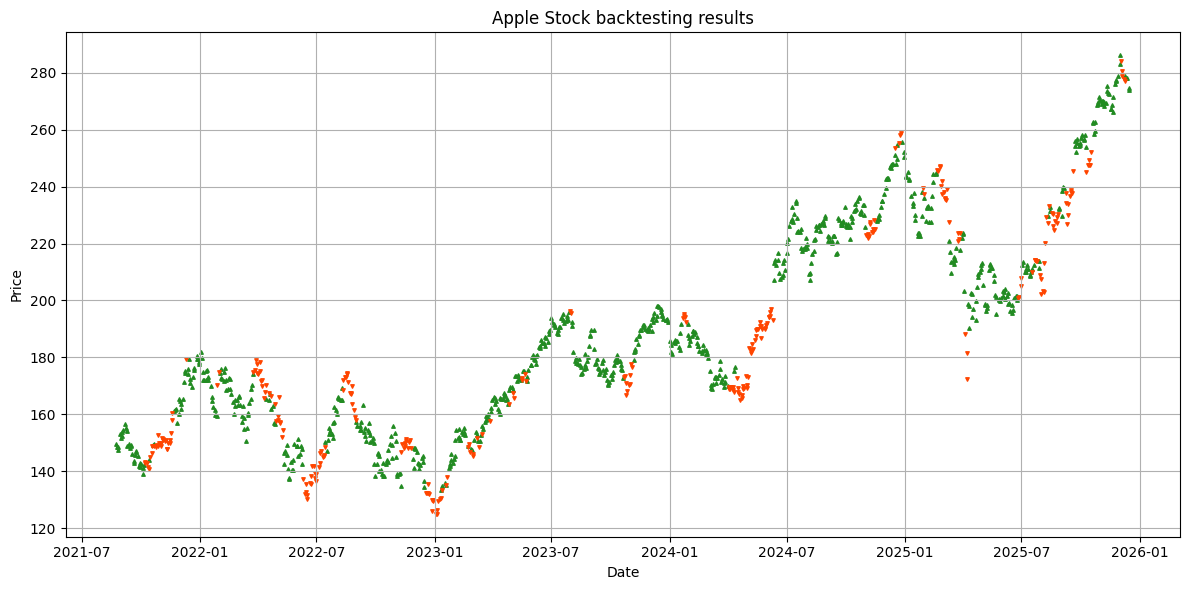

In [93]:
fig, ax = plt.subplots(figsize=(12, 6))
# df.plot(x='date', y='close', ax=ax, label='Close Price', color='lightgray')
correct_actions = df[df['color'] == 'green']
incorrect_actions = df[df['color'] == 'red']
ax.scatter(correct_actions['date'], correct_actions['close'], c='forestgreen', label='Correct Action', marker="^", s=6)
ax.scatter(incorrect_actions['date'], incorrect_actions['close'], c='orangered', label='Incorrect Action', marker="v" , s=6)
ax.set_title("Apple Stock backtesting results")
ax.set_xlabel("Date")
ax.set_ylabel("Price")

ax.grid(True)
fig.tight_layout()
plt.show()

## Confusion Matrix of Apple training

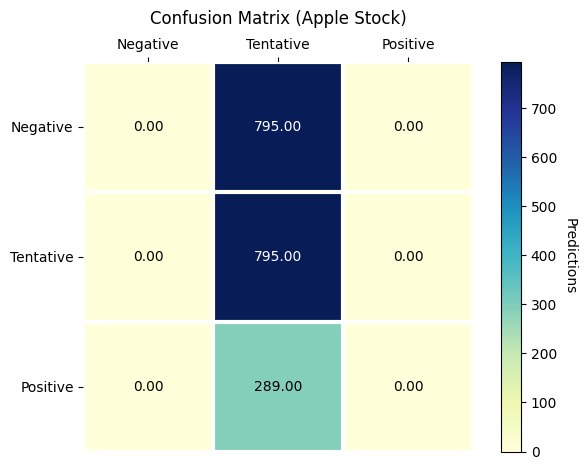

In [97]:
import numpy as np
import matplotlib

truth = ["Negative", "Tentative", "Positive"]
prediction = ["Negative", "Tentative", "Positive"]

truth_table = np.array([[true_negative, true_tentative, true_positive],
                        [false_negative, true_tentative, false_positive],
                        [false_negative, false_tentative, true_positive]])
fig, ax = plt.subplots()
im = ax.imshow(truth_table, cmap="YlGnBu")
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Predictions", rotation=-90, va="bottom")


ax.set_xticks(range(len(prediction)), labels=prediction,
              ha="center", rotation_mode="anchor")
ax.set_yticks(range(len(truth)), labels=truth)
ax.tick_params(top=True, bottom=False,
                labeltop=True, labelbottom=False)
ax.spines[:].set_visible(False)

ax.set_xticks(np.arange(len(prediction)+1)-.5, minor=True)
ax.set_yticks(np.arange(len(truth)+1)-.5, minor=True)
ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
ax.tick_params(which="minor", bottom=False, left=False)
valfmt = matplotlib.ticker.StrMethodFormatter("{x:.2f}")
data = im.get_array()
threshold = im.norm(data.max())/2.
# Set default alignment to center, but allow it to be
    # overwritten by textkw.
kw = dict(horizontalalignment="center",
            verticalalignment="center")
texts = []
textcolors=("black", "white")
for i in range(len(truth)):
    for j in range(len(prediction)):
        # text = ax.text(j, i, truth_table[i, j].round(4),
        #                ha="center", va="center", color="w")
        kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
        text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
        texts.append(text)

ax.set_title("Confusion Matrix (Apple Stock)", pad=10)
fig.tight_layout()
plt.show()

## Summary
🍋 Evaluated the DQN training result


|Date (YYYY-MM-DD)|Version|Created By|  
|--|--|--|
|2026-03-17|1.0|Battogtokh Baasanjav|